In [1]:
# !pip3 install pandas numpy matplotlib scipy

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)

## Configuration

In [34]:
NAME     = "a_1_0"
DATA_DIR = "./data"

# Results that mean the system was unavailable from the client's perspective
UNAVAILABLE_RESULTS = {"TIMEOUT", "NOT_LEADER"}

# Two requests are considered part of the same unavailability window if
# they are sent within this many seconds of each other
GAP_THRESHOLD_SEC = 2.0

## Load client log

In [35]:
path = f"{DATA_DIR}/client_{NAME}.csv"
log = pd.read_csv(path)

log["sent_sec"]     = log["Sent(usec)"]     / 1e6
log["received_sec"] = log["Received(usec)"] / 1e6

# Received=0 means no response — set to NaN
log.loc[log["Received(usec)"] == 0, "received_sec"] = np.nan

log["unavailable"] = log["Result"].isin(UNAVAILABLE_RESULTS)

print(f"Total requests:      {len(log)}")
print(f"OK:                  {(log['Result'] == 'OK').sum()}")
print(f"TIMEOUT:             {(log['Result'] == 'TIMEOUT').sum()}")
print(f"NOT_LEADER:          {(log['Result'] == 'NOT_LEADER').sum()}")
print(f"Unavailable total:   {log['unavailable'].sum()}")
log.head(10)

Total requests:      1713
OK:                  1324
TIMEOUT:             137
NOT_LEADER:          252
Unavailable total:   389


,SeqNo,Sent(usec),Received(usec),Latency(ms),Result,TargetNode,LeaderHint,Term,sent_sec,received_sec,unavailable
0,1773722381,13406297886,0,0.0,NOT_LEADER,2,0,2,13406.297886,NaN,True
1,1773722382,13407798049,13408237811,439.8,OK,0,0,2,13407.798049,13408.237811,False
2,1773722383,13409298217,13409608831,310.6,OK,0,0,2,13409.298217,13409.608831,False
3,1773722384,13410798367,13411111033,312.7,OK,0,0,2,13410.798367,13411.111033,False
4,1773722385,13412298529,13412613324,314.8,OK,0,0,2,13412.298529,13412.613324,False
5,1773722386,13413798687,13414116051,317.4,OK,0,0,2,13413.798687,13414.116051,False
6,1773722387,13415298848,13415619308,320.5,OK,0,0,2,13415.298848,13415.619308,False
7,1773722388,13416799032,13417123002,324.0,OK,0,0,2,13416.799032,13417.123002,False
8,1773722389,13418299195,13418625848,326.7,OK,0,0,2,13418.299195,13418.625848,False
9,1773722390,13419799342,13420127467,328.1,OK,0,0,2,13419.799342,13420.127467,False


## Identify unavailability windows

An unavailability window opens with the first non-OK request after a run of OK requests,
and closes when OK requests resume. The window duration is measured as:

```
window_end   = sent_sec of first OK request after the window
window_start = sent_sec of first unavailable request in the window
duration     = window_end - window_start
```

In [36]:
log = log.sort_values("sent_sec").reset_index(drop=True)

windows = []
in_window  = False
window_start = None
window_requests = []

for _, row in log.iterrows():
    if not in_window and row["unavailable"]:
        # Window opens
        in_window    = True
        window_start = row["sent_sec"]
        window_requests = [row]

    elif in_window and row["unavailable"]:
        window_requests.append(row)

    elif in_window and not row["unavailable"]:
        # Window closes — first OK request
        window_end = row["sent_sec"]
        duration_ms = (window_end - window_start) * 1000

        n_timeout    = sum(1 for r in window_requests if r["Result"] == "TIMEOUT")
        n_not_leader = sum(1 for r in window_requests if r["Result"] == "NOT_LEADER")

        windows.append({
            "window_start_sec": window_start,
            "window_end_sec":   window_end,
            "duration_ms":      duration_ms,
            "n_requests":       len(window_requests),
            "n_timeout":        n_timeout,
            "n_not_leader":     n_not_leader,
        })

        in_window = False
        window_requests = []

# Handle window still open at end of log
if in_window:
    last_sent = window_requests[-1]["sent_sec"]
    duration_ms = (last_sent - window_start) * 1000
    n_timeout    = sum(1 for r in window_requests if r["Result"] == "TIMEOUT")
    n_not_leader = sum(1 for r in window_requests if r["Result"] == "NOT_LEADER")
    windows.append({
        "window_start_sec": window_start,
        "window_end_sec":   np.nan,
        "duration_ms":      duration_ms,
        "n_requests":       len(window_requests),
        "n_timeout":        n_timeout,
        "n_not_leader":     n_not_leader,
    })
    print("[WARN] Log ends while still in an unavailability window")

windows_df = pd.DataFrame(windows)
print(f"\nFound {len(windows_df)} unavailability windows")
windows_df

[WARN] Log ends while still in an unavailability window

Found 120 unavailability windows


,window_start_sec,window_end_sec,duration_ms,n_requests,n_timeout,n_not_leader
0,13406.297886,13407.798049,1500.163,1,0,1
1,13427.300151,13433.300723,6000.572,4,1,3
2,13457.303345,13463.304130,6000.785,3,1,2
3,13485.806863,13491.807469,6000.606,4,1,3
4,13514.310210,13518.810678,4500.468,3,1,2
...,...,...,...,...,...,...
115,15956.596696,15964.097911,7501.215,5,2,3
116,15976.099274,15979.099611,3000.337,2,0,2
117,16003.102016,16013.603171,10501.155,6,2,4
118,16036.105994,16040.606530,4500.536,3,1,2


## Summary statistics

In [37]:
ms = windows_df["duration_ms"].dropna()
n  = len(ms)
sem  = ms.std() / np.sqrt(n)
ci95 = 1.96 * sem

total_runtime_sec = log["sent_sec"].max() - log["sent_sec"].min()
total_unavail_sec = windows_df["duration_ms"].sum() / 1000
availability_pct  = 100 * (1 - total_unavail_sec / total_runtime_sec)

print(f"Scheme: {NAME}")
print(f"\n--- Unavailability window duration (ms) ---")
print(ms.describe(percentiles=[0.25, 0.5, 0.75, 0.95]).to_string())
print(f"\nMean:        {ms.mean():.1f} ms  ±{ci95:.1f} (95% CI)")
print(f"Median:      {ms.median():.1f} ms")
print(f"p95:         {ms.quantile(0.95):.1f} ms")
print(f"\nTotal unavailability: {total_unavail_sec*1000:.0f} ms over {total_runtime_sec:.1f}s runtime")
print(f"Availability:         {availability_pct:.3f}%")

Scheme: a_1_0

--- Unavailability window duration (ms) ---
count      120.000000
mean      5449.302467
std       8661.664783
min       1500.139000
25%       3000.323250
50%       3000.465500
75%       6000.708500
95%      10501.219450
max      93010.681000

Mean:        5449.3 ms  ±1549.8 (95% CI)
Median:      3000.5 ms
p95:         10501.2 ms

Total unavailability: 653916 ms over 2679.2s runtime
Availability:         75.592%


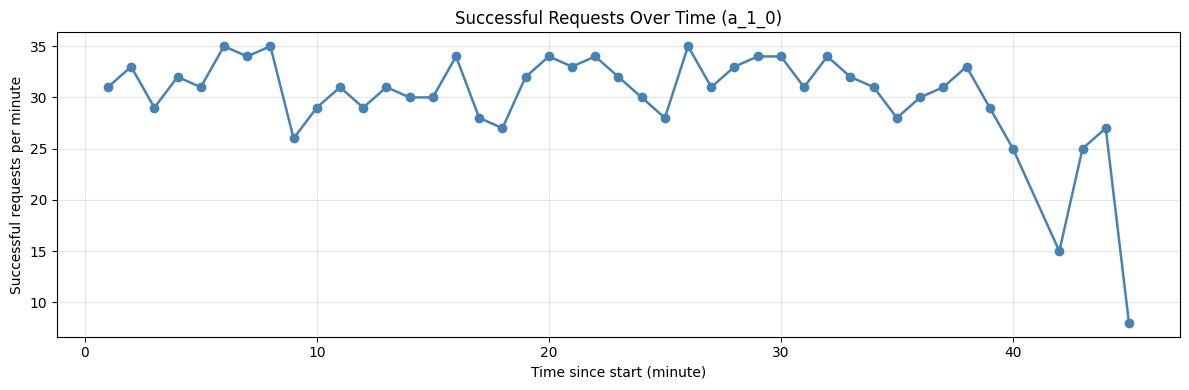

In [38]:
ok_per_min = (
    log.loc[log["Result"] == "OK"]
       .assign(minute=lambda d: ((d["sent_sec"] - log["sent_sec"].min()) // 60).astype(int) + 1)
       .groupby("minute")
       .size()
       .rename("successful_requests")
       .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    ok_per_min["minute"],
    ok_per_min["successful_requests"],
    marker="o",
    linewidth=1.8,
    color="steelblue"
)

ax.set_xlabel("Time since start (minute)")
ax.set_ylabel("Successful requests per minute")
ax.set_title(f"Successful Requests Over Time ({NAME})")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Plots

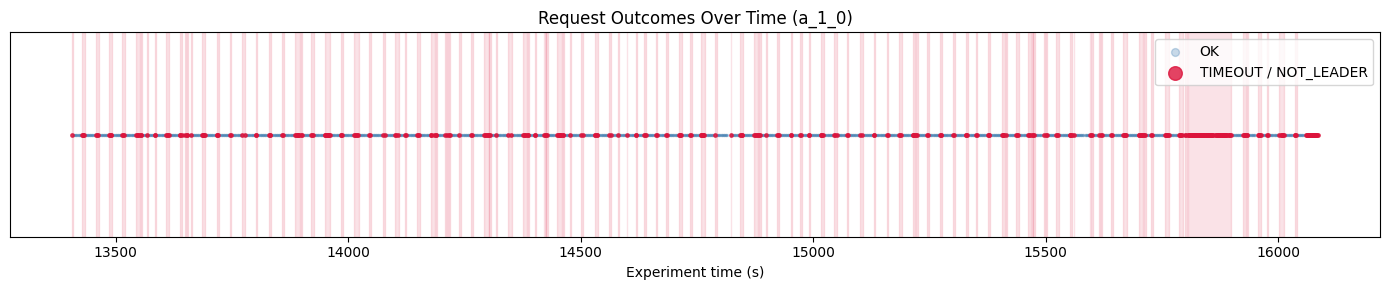

In [39]:
# ── Request outcome timeline ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 3))

ok_rows  = log[~log["unavailable"]]
bad_rows = log[log["unavailable"]]

ax.scatter(ok_rows["sent_sec"],  np.ones(len(ok_rows)),  c="steelblue",
           s=2, alpha=0.3, label="OK")
ax.scatter(bad_rows["sent_sec"], np.ones(len(bad_rows)), c="crimson",
           s=6, alpha=0.8, label="TIMEOUT / NOT_LEADER")

# Shade unavailability windows
for _, w in windows_df.iterrows():
    ax.axvspan(w["window_start_sec"], w["window_end_sec"],
               color="crimson", alpha=0.12)

ax.set_xlabel("Experiment time (s)")
ax.set_yticks([])
ax.set_title(f"Request Outcomes Over Time ({NAME})")
ax.legend(loc="upper right", markerscale=4)
plt.tight_layout()
plt.show()

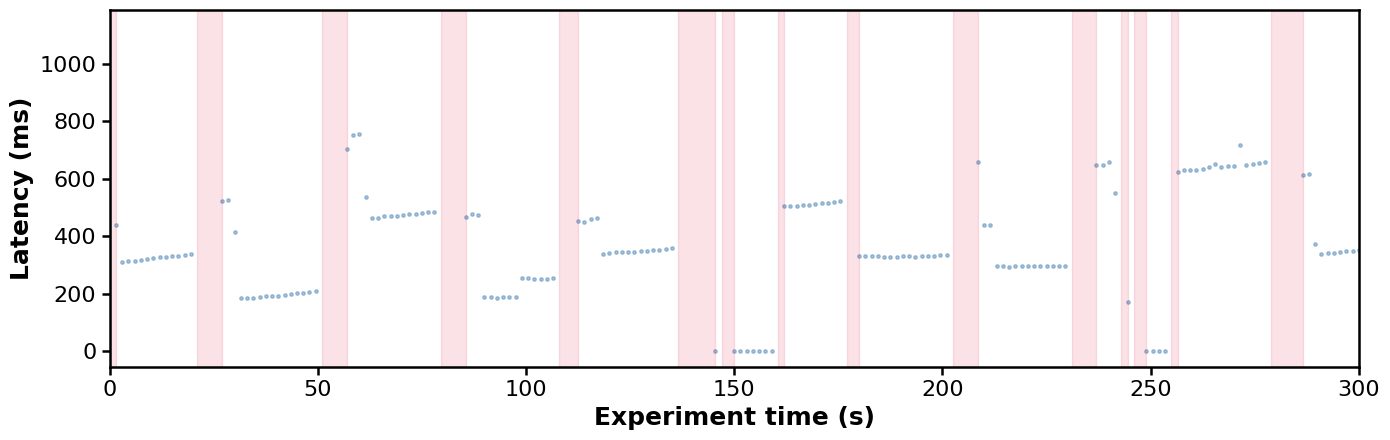

In [40]:
# ── Latency over time (OK requests only) ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4.5))

t0 = log["sent_sec"].min()
ok_rows = log[log["Result"] == "OK"]

ax.scatter(
    ok_rows["sent_sec"] - t0,
    ok_rows["Latency(ms)"],
    s=6,
    alpha=0.45,
    color="steelblue",
    label="OK request"
)

for i, (_, w) in enumerate(windows_df.iterrows()):
    x0 = w["window_start_sec"] - t0
    x1 = (w["window_end_sec"] if pd.notna(w["window_end_sec"]) else log["sent_sec"].max()) - t0
    ax.axvspan(
        x0, x1,
        color="crimson",
        alpha=0.12,
        label="Unavailable window" if i == 0 else "_nolegend_"
    )

ax.set_xlim(0, 300)
ax.set_xlabel("Experiment time (s)", fontsize=18, fontweight="bold")
ax.set_ylabel("Latency (ms)", fontsize=18, fontweight="bold")

ax.tick_params(axis="both", labelsize=16, width=1.8, length=6)

for spine in ax.spines.values():
    spine.set_linewidth(1.8)

plt.tight_layout()
plt.show()

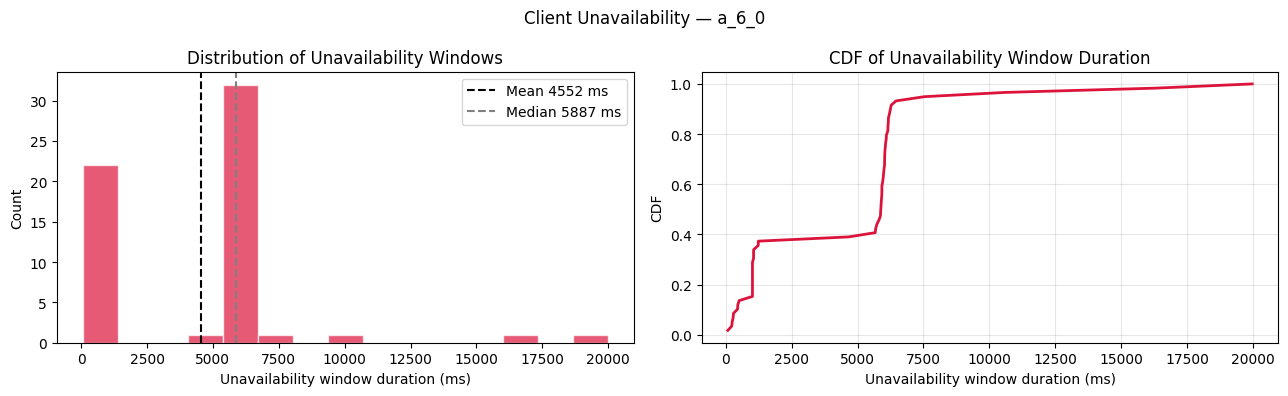

In [11]:
# ── Unavailability window duration distribution ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(windows_df["duration_ms"].dropna(), bins=15, edgecolor="white", color="crimson", alpha=0.7)
ax.axvline(ms.mean(),   color="black",  linestyle="--", label=f"Mean {ms.mean():.0f} ms")
ax.axvline(ms.median(), color="gray",   linestyle="--", label=f"Median {ms.median():.0f} ms")
ax.set_xlabel("Unavailability window duration (ms)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Unavailability Windows")
ax.legend()

# CDF
ax = axes[1]
sorted_ms = np.sort(ms)
cdf = np.arange(1, len(sorted_ms) + 1) / len(sorted_ms)
ax.plot(sorted_ms, cdf, color="crimson", linewidth=2)
ax.set_xlabel("Unavailability window duration (ms)")
ax.set_ylabel("CDF")
ax.set_title("CDF of Unavailability Window Duration")
ax.grid(True, alpha=0.3)

plt.suptitle(f"Client Unavailability — {NAME}")
plt.tight_layout()
plt.show()

---
## Multi-scheme comparison

In [12]:
TIMEOUT_PARAMS = [
    (750,  1500),
    (1000, 2000),
    (1500, 3000),
    (2000, 4000),
]

ACCRUAL_PARAMS = [0.5, 0.75, 1.0, 1.5]

def timeout_name(t, two_t): return f"t_{t}_{two_t}"
def accrual_name(phi):      return f"a_{str(phi).replace('.', '_')}"

In [13]:
def analyze_client(name, data_dir,
                   unavailable_results=None,
                   gap_threshold_sec=2.0):
    """Load a client log and return (windows_df, summary_dict)."""
    if unavailable_results is None:
        unavailable_results = {"TIMEOUT", "NOT_LEADER"}

    try:
        log = pd.read_csv(f"{data_dir}/client_{name}.csv")
    except FileNotFoundError as e:
        print(f"  [SKIP] {name}: {e}")
        return pd.DataFrame(), None

    log["sent_sec"]     = log["Sent(usec)"]     / 1e6
    log["received_sec"] = log["Received(usec)"] / 1e6
    log.loc[log["Received(usec)"] == 0, "received_sec"] = np.nan
    log["unavailable"]  = log["Result"].isin(unavailable_results)
    log = log.sort_values("sent_sec").reset_index(drop=True)

    # Identify windows
    windows = []
    in_window, window_start, window_requests = False, None, []

    for _, row in log.iterrows():
        if not in_window and row["unavailable"]:
            in_window = True
            window_start = row["sent_sec"]
            window_requests = [row]
        elif in_window and row["unavailable"]:
            window_requests.append(row)
        elif in_window and not row["unavailable"]:
            duration_ms = (row["sent_sec"] - window_start) * 1000
            windows.append({
                "window_start_sec": window_start,
                "window_end_sec":   row["sent_sec"],
                "duration_ms":      duration_ms,
                "n_requests":       len(window_requests),
                "n_timeout":        sum(1 for r in window_requests if r["Result"] == "TIMEOUT"),
                "n_not_leader":     sum(1 for r in window_requests if r["Result"] == "NOT_LEADER"),
            })
            in_window, window_requests = False, []

    if in_window:
        last_sent = window_requests[-1]["sent_sec"]
        windows.append({
            "window_start_sec": window_start,
            "window_end_sec":   np.nan,
            "duration_ms":      (last_sent - window_start) * 1000,
            "n_requests":       len(window_requests),
            "n_timeout":        sum(1 for r in window_requests if r["Result"] == "TIMEOUT"),
            "n_not_leader":     sum(1 for r in window_requests if r["Result"] == "NOT_LEADER"),
        })

    windows_df = pd.DataFrame(windows)

    if windows_df.empty:
        return windows_df, None

    ms   = windows_df["duration_ms"].dropna()
    n    = len(ms)
    sem  = ms.std() / np.sqrt(n) if n > 1 else 0
    ci95 = 1.96 * sem

    total_runtime_sec = log["sent_sec"].max() - log["sent_sec"].min()
    total_unavail_sec = ms.sum() / 1000

    summary = {
        "n_windows":          n,
        "mean_ms":            ms.mean(),
        "std_ms":             ms.std(),
        "sem_ms":             sem,
        "ci95_ms":            ci95,
        "median_ms":          ms.median(),
        "p25_ms":             ms.quantile(0.25),
        "p75_ms":             ms.quantile(0.75),
        "p95_ms":             ms.quantile(0.95),
        "total_unavail_ms":   total_unavail_sec * 1000,
        "availability_pct":   100 * (1 - total_unavail_sec / total_runtime_sec),
    }
    return windows_df, summary

In [14]:
client_windows   = {}
client_summaries = {}

print("=== Timeout schemes ===")
for (t, two_t) in TIMEOUT_PARAMS:
    name = timeout_name(t, two_t)
    w, s = analyze_client(name, DATA_DIR)
    client_windows[name]   = w
    client_summaries[name] = s
    if s:
        print(f"  {name:20s}  windows={s['n_windows']:3d}  "
              f"mean={s['mean_ms']:7.1f} ms ±{s['ci95_ms']:.1f}  "
              f"availability={s['availability_pct']:.3f}%")

print("\n=== Accrual schemes ===")
for phi in ACCRUAL_PARAMS:
    name = accrual_name(phi)
    w, s = analyze_client(name, DATA_DIR)
    client_windows[name]   = w
    client_summaries[name] = s
    if s:
        print(f"  {name:20s}  windows={s['n_windows']:3d}  "
              f"mean={s['mean_ms']:7.1f} ms ±{s['ci95_ms']:.1f}  "
              f"availability={s['availability_pct']:.3f}%")

=== Timeout schemes ===
  [SKIP] t_750_1500: [Errno 2] No such file or directory: './data/client_t_750_1500.csv'
  t_1000_2000           windows=220  mean= 1758.4 ms ±166.7  availability=90.136%
  t_1500_3000           windows=169  mean= 2054.4 ms ±204.4  availability=88.690%
  t_2000_4000           windows=216  mean= 2588.8 ms ±216.5  availability=86.737%

=== Accrual schemes ===
  a_0_5                 windows=479  mean= 2699.7 ms ±97.3  availability=84.304%
  a_0_75                windows=367  mean= 5763.4 ms ±880.0  availability=66.082%
  a_1_0                 windows=120  mean= 5449.3 ms ±1549.8  availability=75.592%
  a_1_5                 windows= 40  mean= 5175.6 ms ±546.6  availability=80.792%


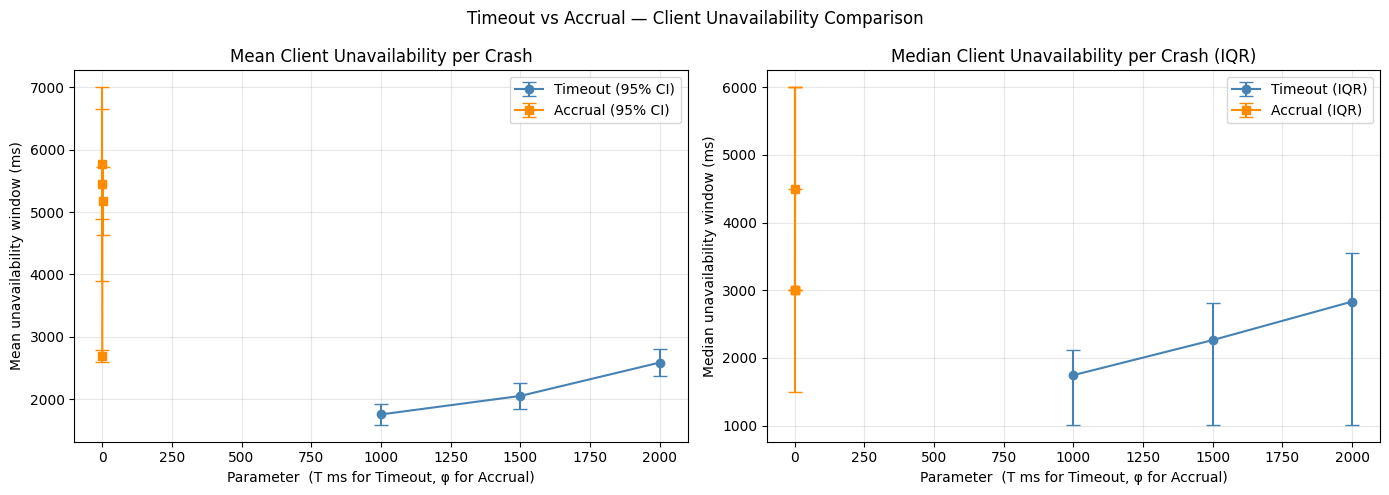

In [15]:
def prep(params, name_fn, label_fn, summaries):
    out = []
    for p in params:
        name = name_fn(*p) if isinstance(p, tuple) else name_fn(p)
        s    = summaries.get(name)
        if s:
            lbl = label_fn(*p) if isinstance(p, tuple) else label_fn(p)
            out.append((lbl, s))
    return out

t_series = prep(TIMEOUT_PARAMS, timeout_name, lambda t, two_t: t,   client_summaries)
a_series = prep(ACCRUAL_PARAMS, accrual_name, lambda phi: phi,       client_summaries)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean + 95% CI
ax = axes[0]
for series, marker, color, label in [
    (t_series, "o", "steelblue",  "Timeout"),
    (a_series, "s", "darkorange", "Accrual"),
]:
    if not series: continue
    xs    = [x for x, _ in series]
    means = [s["mean_ms"]  for _, s in series]
    ci95  = [s["ci95_ms"]  for _, s in series]
    ax.errorbar(xs, means, yerr=ci95, marker=marker, color=color,
                capsize=5, linewidth=1.5, label=f"{label} (95% CI)")
ax.set_xlabel("Parameter  (T ms for Timeout, φ for Accrual)")
ax.set_ylabel("Mean unavailability window (ms)")
ax.set_title("Mean Client Unavailability per Crash")
ax.legend()
ax.grid(True, alpha=0.3)

# Median + IQR
ax = axes[1]
for series, marker, color, label in [
    (t_series, "o", "steelblue",  "Timeout"),
    (a_series, "s", "darkorange", "Accrual"),
]:
    if not series: continue
    xs      = [x for x, _ in series]
    medians = [s["median_ms"] for _, s in series]
    yerr_lo = [s["median_ms"] - s["p25_ms"] for _, s in series]
    yerr_hi = [s["p75_ms"] - s["median_ms"] for _, s in series]
    ax.errorbar(xs, medians, yerr=[yerr_lo, yerr_hi], marker=marker, color=color,
                capsize=5, linewidth=1.5, label=f"{label} (IQR)")
ax.set_xlabel("Parameter  (T ms for Timeout, φ for Accrual)")
ax.set_ylabel("Median unavailability window (ms)")
ax.set_title("Median Client Unavailability per Crash (IQR)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("Timeout vs Accrual — Client Unavailability Comparison")
plt.tight_layout()
plt.show()

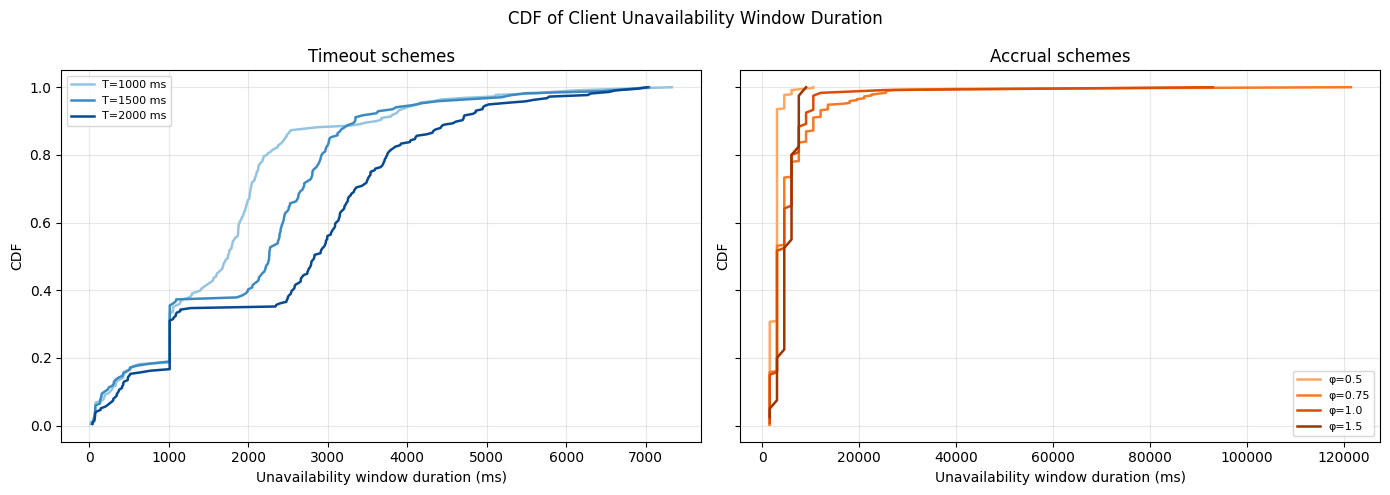

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, params, name_fn, label_fn, cmap, scheme_label in [
    (axes[0], TIMEOUT_PARAMS, timeout_name, lambda t, two_t: f"T={t} ms",  plt.cm.Blues,   "Timeout"),
    (axes[1], ACCRUAL_PARAMS, accrual_name, lambda phi: f"φ={phi}",        plt.cm.Oranges, "Accrual"),
]:
    valid  = [(p, name_fn(*p) if isinstance(p, tuple) else name_fn(p)) for p in params]
    valid  = [(p, n) for p, n in valid
              if not client_windows.get(n, pd.DataFrame()).empty]
    colors = [cmap(0.4 + 0.5 * i / max(len(valid) - 1, 1)) for i in range(len(valid))]

    for (p, name), color in zip(valid, colors):
        ms  = np.sort(client_windows[name]["duration_ms"].dropna().values)
        cdf = np.arange(1, len(ms) + 1) / len(ms)
        lbl = label_fn(*p) if isinstance(p, tuple) else label_fn(p)
        ax.plot(ms, cdf, color=color, linewidth=1.8, label=lbl)

    ax.set_xlabel("Unavailability window duration (ms)")
    ax.set_ylabel("CDF")
    ax.set_title(f"{scheme_label} schemes")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("CDF of Client Unavailability Window Duration")
plt.tight_layout()
plt.show()

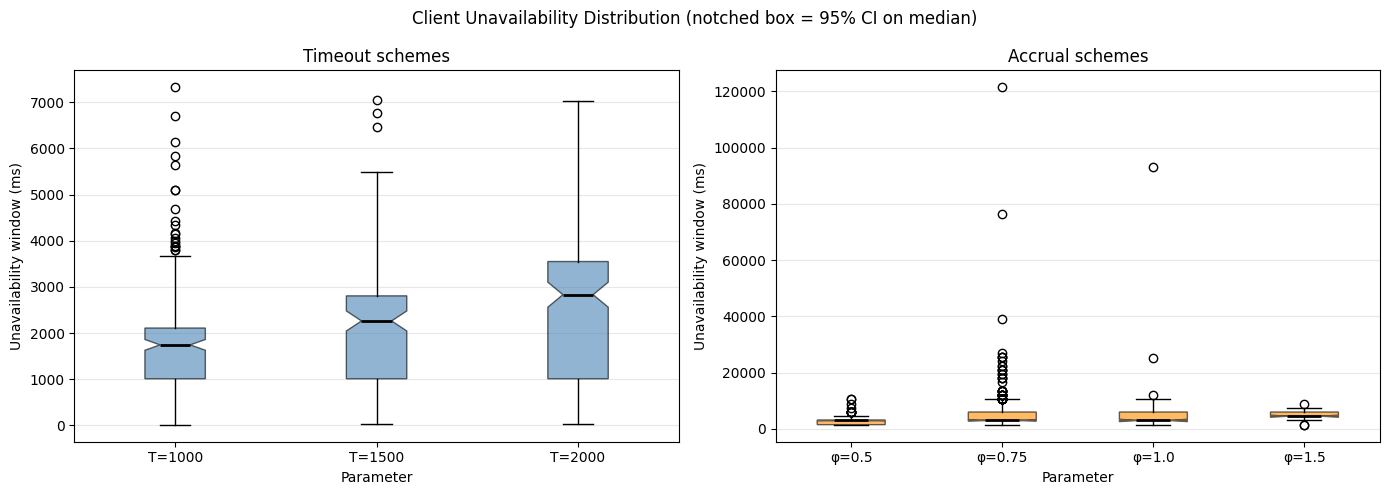

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, params, name_fn, label_fn, color, scheme_label in [
    (axes[0], TIMEOUT_PARAMS, timeout_name, lambda t, two_t: f"T={t}",  "steelblue",  "Timeout"),
    (axes[1], ACCRUAL_PARAMS, accrual_name, lambda phi: f"φ={phi}",     "darkorange", "Accrual"),
]:
    groups, xlabels = [], []
    for p in params:
        name = name_fn(*p) if isinstance(p, tuple) else name_fn(p)
        w    = client_windows.get(name, pd.DataFrame())
        if not w.empty:
            groups.append(w["duration_ms"].dropna().values)
            xlabels.append(label_fn(*p) if isinstance(p, tuple) else label_fn(p))

    if groups:
        bp = ax.boxplot(groups, patch_artist=True, notch=True,
                        medianprops=dict(color="black", linewidth=2))
        for patch in bp["boxes"]:
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
        ax.set_xticks(range(1, len(xlabels) + 1))
        ax.set_xticklabels(xlabels)

    ax.set_xlabel("Parameter")
    ax.set_ylabel("Unavailability window (ms)")
    ax.set_title(f"{scheme_label} schemes")
    ax.grid(True, axis="y", alpha=0.3)

plt.suptitle("Client Unavailability Distribution (notched box = 95% CI on median)")
plt.tight_layout()
plt.show()

## Summary table

In [18]:
rows = []
for (t, two_t) in TIMEOUT_PARAMS:
    name = timeout_name(t, two_t)
    s    = client_summaries.get(name)
    if s: rows.append({"scheme": "Timeout", "param": t,   "name": name, **s})

for phi in ACCRUAL_PARAMS:
    name = accrual_name(phi)
    s    = client_summaries.get(name)
    if s: rows.append({"scheme": "Accrual", "param": phi, "name": name, **s})

summary_table = pd.DataFrame(rows).set_index(["scheme", "param"])
summary_table[[
    "name", "n_windows", "mean_ms", "ci95_ms",
    "median_ms", "p25_ms", "p75_ms", "p95_ms",
    "total_unavail_ms", "availability_pct"
]].round(1)

name  n_windows  mean_ms  ci95_ms  median_ms  p25_ms  \
scheme  param                                                                  
Timeout 1000.00  t_1000_2000        220   1758.4    166.7     1745.8  1011.4   
        1500.00  t_1500_3000        169   2054.4    204.4     2264.2  1011.4   
        2000.00  t_2000_4000        216   2588.8    216.5     2833.0  1011.4   
Accrual 0.50           a_0_5        479   2699.7     97.3     3000.3  1500.2   
        0.75          a_0_75        367   5763.4    880.0     3000.5  3000.3   
        1.00           a_1_0        120   5449.3   1549.8     3000.5  3000.3   
        1.50           a_1_5         40   5175.6    546.6     4500.6  4500.5   

                 p75_ms   p95_ms  total_unavail_ms  availability_pct  
scheme  param                                                         
Timeout 1000.00  2110.8   4145.1          386850.5              90.1  
        1500.00  2807.8   4133.2          347191.3              88.7  
        2000.00  3551.4   5078.5          559190.8              86.7  
Accrual 0.50     3000.3   4500.5         1293144.9              84.3  
        0.75     6000.7  15602.2         2115184.0              66.1  
        1.00     6000.7  10501.2          653916.3              75.6  
        1.50     6000.8   7501.0          207024.7              80.8